# Upsell Opportunity Detection - Model Training

## Purpose
This notebook trains multiple machine learning models to predict upsell opportunities:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- Gradient Boosting Classifier
- Support Vector Machine (SVM)
- **Ensemble Models:**
  - Voting Classifier (Soft Voting)
  - Stacking Classifier

## Workflow
1. Data Loading & Feature Engineering
2. Hyperparameter Tuning (Optional)
3. Model Training
4. Cross-Validation
5. Ensemble Models
6. Model Evaluation & Comparison
7. Save All Models

**All trained models are automatically saved to the `models/` directory.**

In [1]:
# Install required packages
!uv add scikit-learn xgboost matplotlib seaborn pandas numpy openpyxl joblib

Resolved 54 packages in 880ms
Audited 47 packages in 4ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Create Target Variable

In [3]:
# Load the dataset
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns


In [4]:
# Replicate feature engineering from EDA
df_upsell = df.copy()

# Convert date columns to datetime
date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
for col in date_columns:
    if col in df_upsell.columns:
        df_upsell[col] = pd.to_datetime(df_upsell[col], errors='coerce')

# Calculate contract duration (months)
if 'contract_start_date' in df_upsell.columns:
    today = pd.Timestamp.now()
    df_upsell['contract_duration_months'] = (
        (today - df_upsell['contract_start_date']).dt.days / 30.44
    ).round(1)
    df_upsell['contract_duration_months'] = df_upsell['contract_duration_months'].fillna(0).clip(lower=0)

# Calculate days until renewal
if 'renewal_date' in df_upsell.columns:
    df_upsell['days_until_renewal'] = (
        df_upsell['renewal_date'] - today
    ).dt.days
    df_upsell['days_until_renewal'] = df_upsell['days_until_renewal'].fillna(0)

# Calculate available licenses
if 'licenses_total' in df_upsell.columns and 'licenses_used' in df_upsell.columns:
    df_upsell['licenses_available'] = df_upsell['licenses_total'] - df_upsell['licenses_used']
    df_upsell['utilization_ratio'] = np.where(
        df_upsell['licenses_total'] > 0,
        df_upsell['licenses_used'] / df_upsell['licenses_total'],
        0
    )

# Calculate potential ARR increase
if 'utilization_percentage' in df_upsell.columns and 'arr' in df_upsell.columns:
    df_upsell['potential_arr_increase'] = np.where(
        df_upsell['utilization_percentage'] > 0,
        df_upsell['arr'] * (100 / df_upsell['utilization_percentage'] - 1),
        0
    )
    df_upsell['potential_arr_increase'] = df_upsell['potential_arr_increase'].clip(lower=0)

print("Feature engineering completed!")

Feature engineering completed!


In [5]:
# Create target variable using rule-based logic (same as EDA)
# Rule 1: High License Utilization (>85%) → Seat Expansion
if 'utilization_percentage' in df_upsell.columns:
    df_upsell['flag_seat_expansion'] = df_upsell['utilization_percentage'] >= 85

# Rule 2: Account Growth Potential (High utilization + Good health)
if 'utilization_percentage' in df_upsell.columns and 'health_score' in df_upsell.columns:
    df_upsell['flag_capacity_increase'] = (
        (df_upsell['utilization_percentage'] >= 75) & 
        (df_upsell['health_score'] >= 70)
    )

# Rule 3: High ARR + Low Utilization → Tier Upgrade Opportunity
if 'arr' in df_upsell.columns and 'utilization_percentage' in df_upsell.columns:
    arr_median = df_upsell['arr'].median()
    df_upsell['flag_tier_upgrade'] = (
        (df_upsell['arr'] >= arr_median) & 
        (df_upsell['utilization_percentage'] < 50)
    )

# Rule 4: Contract Maturity + High Health → Expansion Ready
if ('contract_duration_months' in df_upsell.columns and 
    'health_score' in df_upsell.columns and 
    'utilization_percentage' in df_upsell.columns):
    df_upsell['flag_expansion_ready'] = (
        (df_upsell['contract_duration_months'] >= 12) & 
        (df_upsell['health_score'] >= 75) &
        (df_upsell['utilization_percentage'] >= 70)
    )

# Create overall upsell opportunity score and binary target
upsell_flags = ['flag_seat_expansion', 'flag_capacity_increase', 
                'flag_tier_upgrade', 'flag_expansion_ready']
available_flags = [f for f in upsell_flags if f in df_upsell.columns]

if available_flags:
    df_upsell['upsell_opportunity_score'] = df_upsell[available_flags].sum(axis=1)
    df_upsell['has_upsell_opportunity'] = (df_upsell['upsell_opportunity_score'] > 0).astype(int)
    
    print("Target variable created!")
    print(f"\nUpsell Opportunity Distribution:")
    print(df_upsell['has_upsell_opportunity'].value_counts())
    print(f"\nUpsell Rate: {df_upsell['has_upsell_opportunity'].mean():.2%}")
else:
    # Fallback: use utilization > 85% as target
    df_upsell['has_upsell_opportunity'] = (df_upsell['utilization_percentage'] >= 85).astype(int)
    print("Target variable created using utilization threshold!")
    print(f"\nUpsell Opportunity Distribution:")
    print(df_upsell['has_upsell_opportunity'].value_counts())

Target variable created!

Upsell Opportunity Distribution:
has_upsell_opportunity
0    14594
1    10280
Name: count, dtype: int64

Upsell Rate: 41.33%


## 2. Feature Selection and Preprocessing

In [6]:
# Select features for modeling
numerical_features = [
    'arr', 'mrr', 'health_score', 'risk_score', 'relationship_score',
    'sentiment_score', 'licenses_total', 'licenses_used', 
    'utilization_percentage', 'contract_duration_months', 
    'days_until_renewal', 'licenses_available', 'utilization_ratio',
    'potential_arr_increase'
]

categorical_features = ['industry', 'company_size']

# Check which features exist
available_numerical = [f for f in numerical_features if f in df_upsell.columns]
available_categorical = [f for f in categorical_features if f in df_upsell.columns]

print("Available Numerical Features:")
print(available_numerical)
print(f"\nAvailable Categorical Features:")
print(available_categorical)

# Create feature dataframe
feature_df = df_upsell[available_numerical + available_categorical + ['has_upsell_opportunity']].copy()

# Handle missing values
print(f"\nMissing values before imputation:")
print(feature_df.isnull().sum()[feature_df.isnull().sum() > 0])

# Fill missing values
for col in available_numerical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].median(), inplace=True)

for col in available_categorical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].mode()[0], inplace=True)

print(f"\nMissing values after imputation: {feature_df.isnull().sum().sum()}")

Available Numerical Features:
['arr', 'mrr', 'health_score', 'risk_score', 'relationship_score', 'sentiment_score', 'licenses_total', 'licenses_used', 'utilization_percentage', 'contract_duration_months', 'days_until_renewal', 'licenses_available', 'utilization_ratio', 'potential_arr_increase']

Available Categorical Features:
['industry', 'company_size']

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0


In [7]:
# Encode categorical variables
label_encoders = {}
feature_df_encoded = feature_df.copy()

for col in available_categorical:
    le = LabelEncoder()
    feature_df_encoded[col] = le.fit_transform(feature_df[col].astype(str))
    label_encoders[col] = le
    print(f"{col} encoded: {len(le.classes_)} unique values")

# Prepare X and y
X = feature_df_encoded.drop('has_upsell_opportunity', axis=1)
y = feature_df_encoded['has_upsell_opportunity']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Upsell rate: {y.mean():.2%}")

industry encoded: 16 unique values
company_size encoded: 4 unique values

Feature matrix shape: (24874, 16)
Target distribution:
has_upsell_opportunity
0    14594
1    10280
Name: count, dtype: int64
Upsell rate: 41.33%


In [8]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining set upsell rate: {y_train.mean():.2%}")
print(f"Test set upsell rate: {y_test.mean():.2%}")

# Scale features for models that require scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Training set: 19,899 samples
Test set: 4,975 samples

Training set upsell rate: 41.33%
Test set upsell rate: 41.33%


## 3. Hyperparameter Tuning (Optional)

**Note:** Set `ENABLE_TUNING = False` to skip tuning and use default parameters for faster execution.

In [9]:
# Set to True to enable hyperparameter tuning, False to use default parameters
ENABLE_TUNING = True  # Change to False to skip tuning

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'lbfgs']
    }
}

# Store tuned models
tuned_models = {}

if ENABLE_TUNING:
    print("Starting Hyperparameter Tuning...")
    print("=" * 80)
    print("This may take several minutes. Please be patient...\n")
    
    # Tune Random Forest
    print("Tuning Random Forest...")
    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(
        rf_base, param_grids['Random Forest'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    rf_search.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_search.best_estimator_
    print(f"  Best Score: {rf_search.best_score_:.4f}")
    print(f"  Best Params: {rf_search.best_params_}\n")
    
    # Tune XGBoost
    print("Tuning XGBoost...")
    xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_search = RandomizedSearchCV(
        xgb_base, param_grids['XGBoost'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    xgb_search.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"  Best Score: {xgb_search.best_score_:.4f}")
    print(f"  Best Params: {xgb_search.best_params_}\n")
    
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting...")
    gb_base = GradientBoostingClassifier(random_state=42)
    gb_search = RandomizedSearchCV(
        gb_base, param_grids['Gradient Boosting'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    gb_search.fit(X_train, y_train)
    tuned_models['Gradient Boosting'] = gb_search.best_estimator_
    print(f"  Best Score: {gb_search.best_score_:.4f}")
    print(f"  Best Params: {gb_search.best_params_}\n")
    
    # Tune Logistic Regression
    print("Tuning Logistic Regression...")
    lr_base = LogisticRegression(random_state=42, max_iter=1000)
    lr_search = RandomizedSearchCV(
        lr_base, param_grids['Logistic Regression'],
        n_iter=15, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    lr_search.fit(X_train_scaled, y_train)
    tuned_models['Logistic Regression'] = lr_search.best_estimator_
    print(f"  Best Score: {lr_search.best_score_:.4f}")
    print(f"  Best Params: {lr_search.best_params_}\n")
    
    print("=" * 80)
    print("Hyperparameter tuning completed! ✓")
    print("=" * 80)
else:
    print("Hyperparameter tuning is disabled. Using default parameters.")
    print("Set ENABLE_TUNING = True to enable tuning.")

Starting Hyperparameter Tuning...
This may take several minutes. Please be patient...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}

Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}

Tuning Logistic Regression...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best Score: 0.9232
  Best Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}

Hyperparameter tuning completed! ✓


## 4. Model Training

In [21]:
# Initialize models - use tuned models if available, otherwise use defaults
models = {}

if ENABLE_TUNING and len(tuned_models) > 0:
    models['Logistic Regression'] = tuned_models.get('Logistic Regression', 
        LogisticRegression(random_state=42, max_iter=1000))
    models['Random Forest'] = tuned_models.get('Random Forest',
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    models['XGBoost'] = tuned_models.get('XGBoost',
        xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
    models['Gradient Boosting'] = tuned_models.get('Gradient Boosting',
        GradientBoostingClassifier(random_state=42))
    print("Using tuned hyperparameters for models where available.")
else:
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    }
    print("Using default hyperparameters.")

# Add SVM (not tuned due to computational cost)
models['SVM'] = SVC(probability=True, random_state=42)

# Store results
results = {}
predictions = {}
probabilities = {}

print("\nTraining models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    # Calculate training performance for overfitting check
    if name in ['Logistic Regression', 'SVM']:
        y_train_pred = model.predict(X_train_scaled)
        y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    else:
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:, 1]
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    
    # Store training metrics
    results[name]['Train Accuracy'] = train_accuracy
    results[name]['Train F1'] = train_f1
    results[name]['Train ROC-AUC'] = train_roc_auc
    
    # Calculate overfitting gap
    results[name]['Accuracy Gap'] = train_accuracy - accuracy
    results[name]['F1 Gap'] = train_f1 - f1
    results[name]['ROC-AUC Gap'] = train_roc_auc - roc_auc
    
    print(f"  Test Accuracy: {accuracy:.4f} | Train Accuracy: {train_accuracy:.4f} | Gap: {train_accuracy - accuracy:.4f}")
    print(f"  Test F1-Score: {f1:.4f} | Train F1-Score: {train_f1:.4f} | Gap: {train_f1 - f1:.4f}")
    print(f"  Test ROC-AUC: {roc_auc:.4f} | Train ROC-AUC: {train_roc_auc:.4f} | Gap: {train_roc_auc - roc_auc:.4f}")

print("\n" + "=" * 80)
print("All models trained successfully!")

Using tuned hyperparameters for models where available.

Training models...

Training Logistic Regression...
  Test Accuracy: 0.8496 | Train Accuracy: 0.8471 | Gap: -0.0026
  Test F1-Score: 0.8179 | Train F1-Score: 0.8152 | Gap: -0.0027
  Test ROC-AUC: 0.9235 | Train ROC-AUC: 0.9240 | Gap: 0.0005

Training Random Forest...
  Test Accuracy: 1.0000 | Train Accuracy: 1.0000 | Gap: 0.0000
  Test F1-Score: 1.0000 | Train F1-Score: 1.0000 | Gap: 0.0000
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: 0.0000

Training XGBoost...
  Test Accuracy: 0.9998 | Train Accuracy: 1.0000 | Gap: 0.0002
  Test F1-Score: 0.9998 | Train F1-Score: 1.0000 | Gap: 0.0002
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: 0.0000

Training Gradient Boosting...
  Test Accuracy: 1.0000 | Train Accuracy: 1.0000 | Gap: 0.0000
  Test F1-Score: 1.0000 | Train F1-Score: 1.0000 | Gap: 0.0000
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: -0.0000

Training SVM...
  Test Accuracy: 0.9618 | Train Accuracy: 0.

## 5. Cross-Validation

In [11]:
# Perform cross-validation for more robust evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Performing 5-Fold Cross-Validation...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        X_cv = X_train_scaled.values
    else:
        X_cv = X_train.values
    
    # Cross-validation scores
    cv_accuracy = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_roc_auc = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = {
        'CV Accuracy Mean': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1 Mean': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'CV ROC-AUC Mean': cv_roc_auc.mean(),
        'CV ROC-AUC Std': cv_roc_auc.std()
    }
    
    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"  CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
    print(f"  CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std() * 2:.4f})")

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 80)
print("Cross-Validation Results Summary:")
print(cv_results_df.round(4))

Performing 5-Fold Cross-Validation...

Logistic Regression...
  CV Accuracy: 0.8469 (+/- 0.0044)
  CV F1-Score: 0.8167 (+/- 0.0053)
  CV ROC-AUC: 0.9237 (+/- 0.0062)

Random Forest...
  CV Accuracy: 0.9998 (+/- 0.0004)
  CV F1-Score: 0.9998 (+/- 0.0005)
  CV ROC-AUC: 1.0000 (+/- 0.0000)

XGBoost...
  CV Accuracy: 0.9998 (+/- 0.0002)
  CV F1-Score: 0.9998 (+/- 0.0003)
  CV ROC-AUC: 1.0000 (+/- 0.0000)

Gradient Boosting...
  CV Accuracy: 0.9997 (+/- 0.0006)
  CV F1-Score: 0.9997 (+/- 0.0008)
  CV ROC-AUC: 1.0000 (+/- 0.0001)

SVM...
  CV Accuracy: 0.9585 (+/- 0.0034)
  CV F1-Score: 0.9486 (+/- 0.0044)
  CV ROC-AUC: 0.9939 (+/- 0.0009)

Cross-Validation Results Summary:
                     CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  \
Logistic Regression            0.8469           0.0022      0.8167     0.0027   
Random Forest                  0.9998           0.0002      0.9998     0.0002   
XGBoost                        0.9998           0.0001      0.9998     0.0001   

## 6. Model Performance Comparison

## 6.5. Overfitting Analysis

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          1.0000     1.0000  1.0000    1.0000   1.0000
Gradient Boosting      1.0000     1.0000  1.0000    1.0000   1.0000
XGBoost                0.9998     0.9995  1.0000    0.9998   1.0000
SVM                    0.9618     0.9751  0.9314    0.9527   0.9952
Logistic Regression    0.8496     0.8187  0.8171    0.8179   0.9235


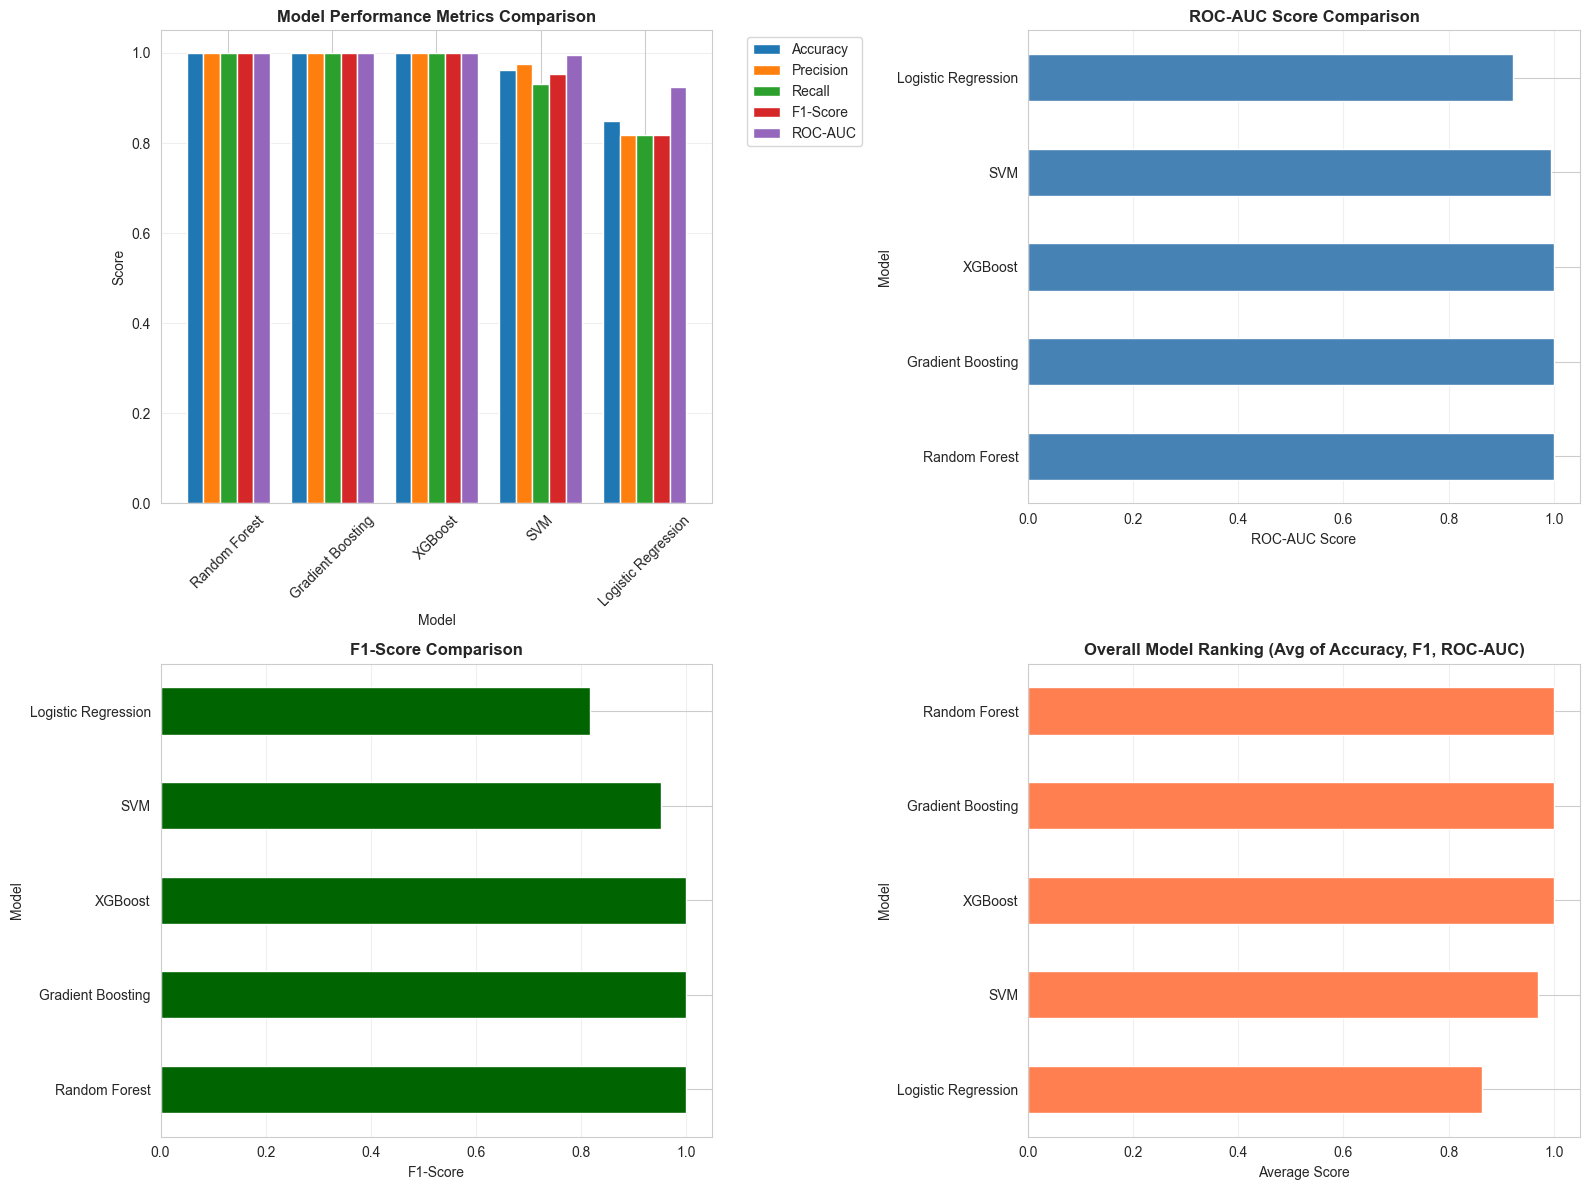

In [12]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Model Performance Comparison:")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df[metrics].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Model Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ROC-AUC Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# F1-Score comparison
results_df['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='darkgreen')
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F1-Score', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
results_df['Overall Score'] = (
    results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
) / 3
overall_score = results_df['Overall Score'].sort_values(ascending=True)
overall_score.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Overall Model Ranking (Avg of Accuracy, F1, ROC-AUC)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. ROC Curves

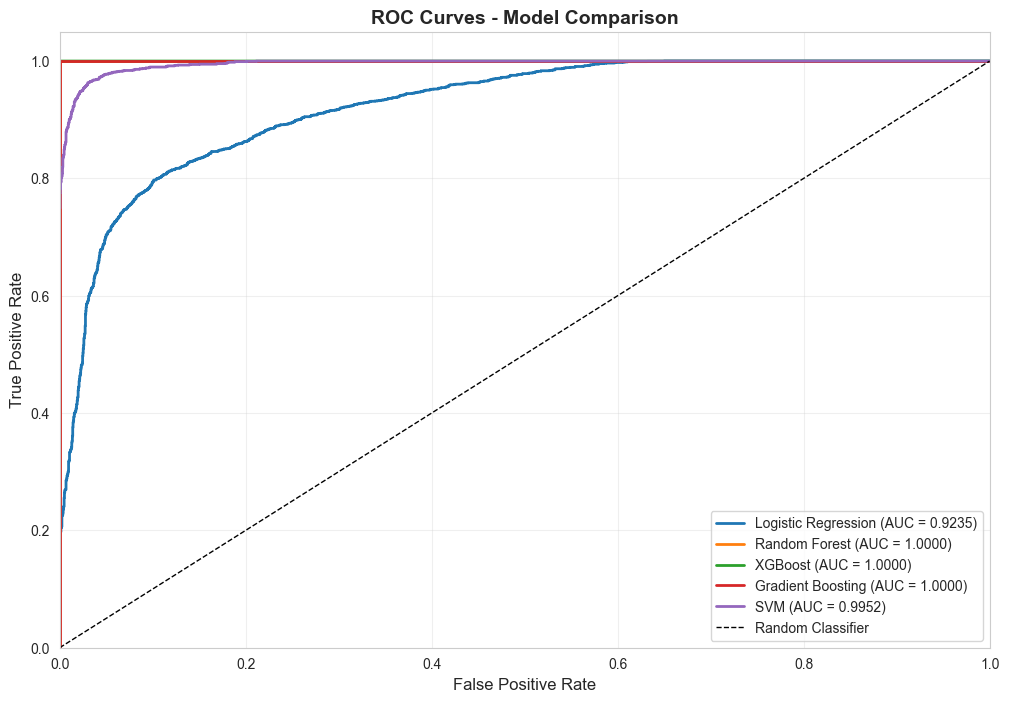

In [13]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Confusion Matrices

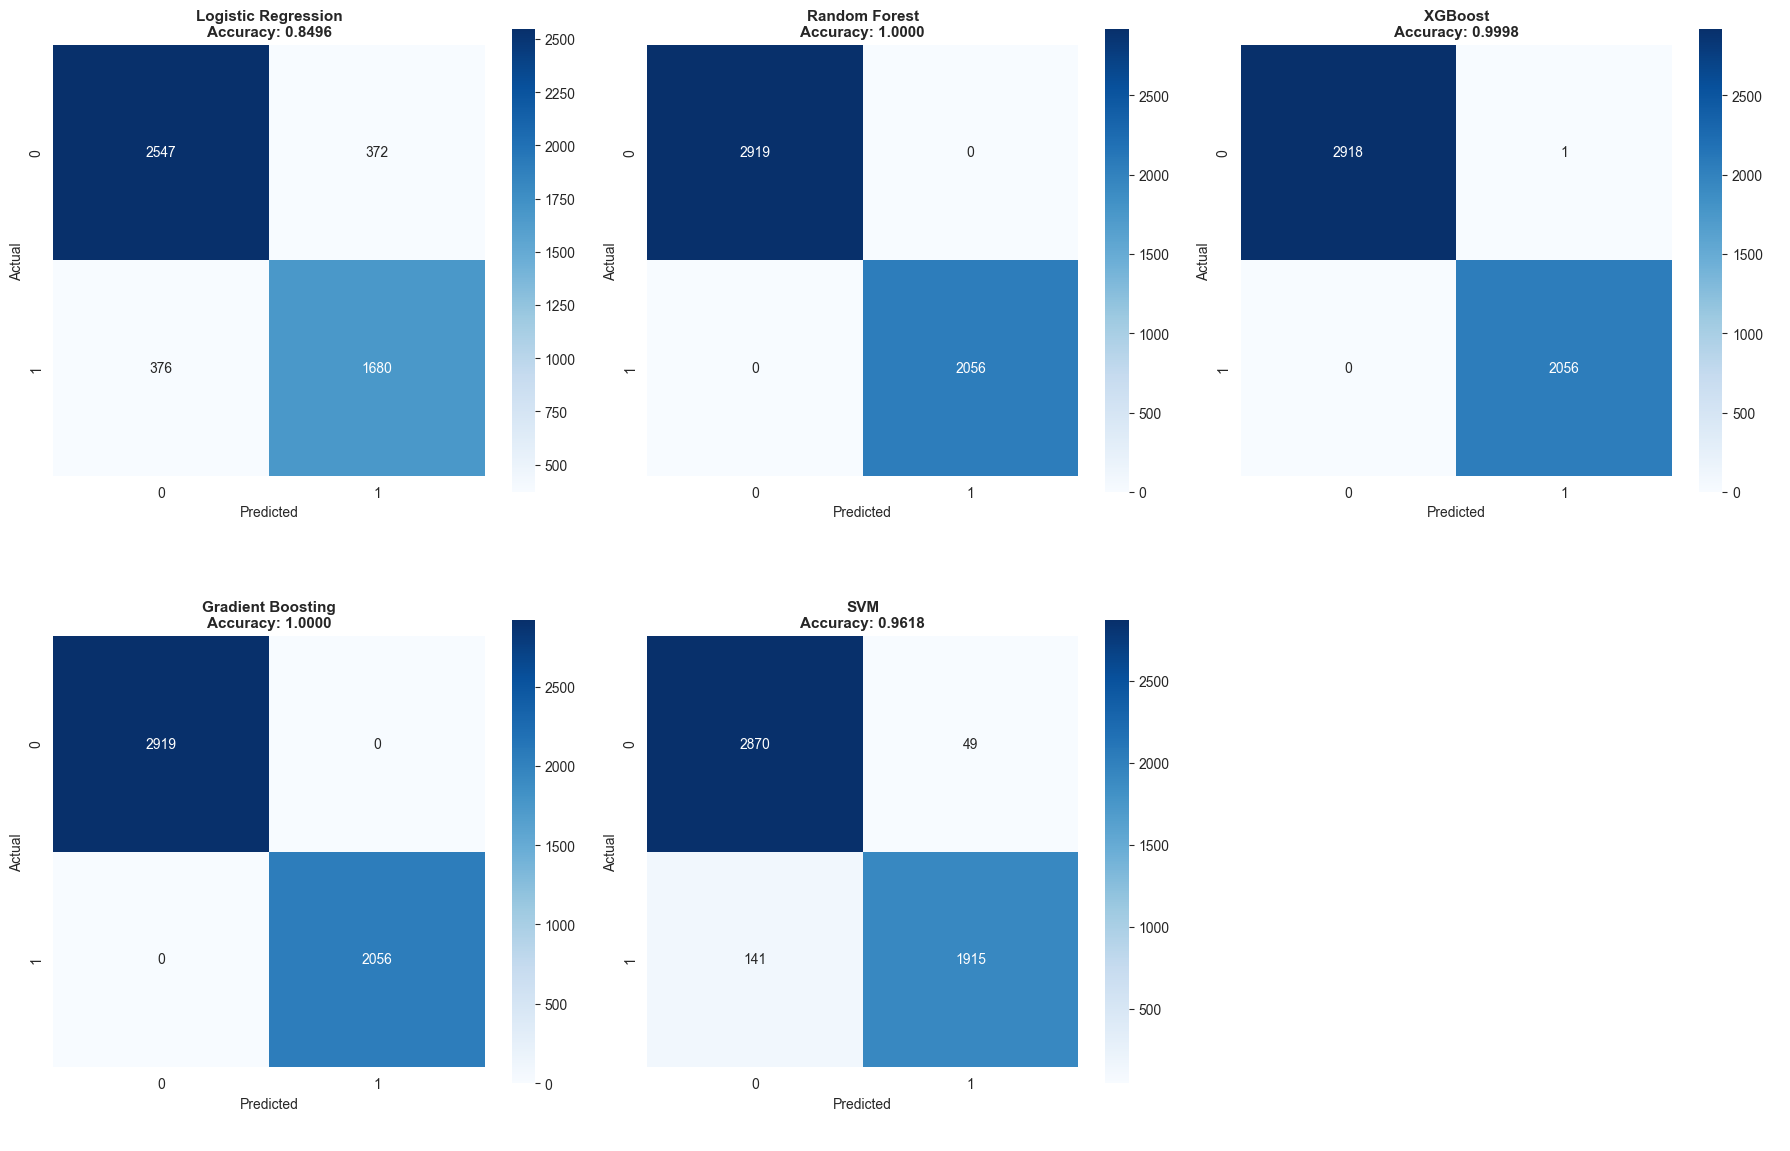

In [14]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'shrink': 0.8}, square=True)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

# Hide the last subplot if odd number of models
if len(models) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 9. Ensemble Models

In [15]:
# Create base models for ensemble
# Use tuned/trained models from the models dictionary

print("Preparing base models for ensemble...")
if ENABLE_TUNING and len(tuned_models) > 0:
    print("  → Using tuned models for ensemble")
    base_models = [
        ('rf', tuned_models.get('Random Forest', models.get('Random Forest'))),
        ('xgb', tuned_models.get('XGBoost', models.get('XGBoost'))),
        ('gb', tuned_models.get('Gradient Boosting', models.get('Gradient Boosting')))
    ]
elif 'models' in globals() and len(models) > 0:
    print("  → Using trained models for ensemble")
    base_models = [
        ('rf', models.get('Random Forest')),
        ('xgb', models.get('XGBoost')),
        ('gb', models.get('Gradient Boosting'))
    ]
else:
    print("  → Using default models for ensemble")
    base_models = [
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
        ('gb', GradientBoostingClassifier(random_state=42))
    ]

# Create Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=base_models,
    voting='soft',
    n_jobs=-1
)

# Create Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Train ensemble models
print("\nTraining Ensemble Models...")
print("=" * 80)

# Train Voting Classifier
print("\nTraining Voting Classifier (Soft Voting)...")
voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)
voting_proba = voting_clf.predict_proba(X_test)[:, 1]

# Train Stacking Classifier
print("Training Stacking Classifier...")
stacking_clf.fit(X_train, y_train)
stacking_pred = stacking_clf.predict(X_test)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]

# Calculate metrics for ensemble models
ensemble_results = {}

for name, y_pred, y_proba in [
    ('Voting Classifier', voting_pred, voting_proba),
    ('Stacking Classifier', stacking_pred, stacking_proba)
]:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    ensemble_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Add ensemble models to main results
results.update(ensemble_results)
predictions['Voting Classifier'] = voting_pred
predictions['Stacking Classifier'] = stacking_pred
probabilities['Voting Classifier'] = voting_proba
probabilities['Stacking Classifier'] = stacking_proba

print("\n" + "=" * 80)
print("Ensemble models trained successfully!")

Preparing base models for ensemble...
  → Using tuned models for ensemble

Training Ensemble Models...

Training Voting Classifier (Soft Voting)...
Training Stacking Classifier...

Voting Classifier:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

Stacking Classifier:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

Ensemble models trained successfully!


Updated Model Performance Comparison (Including Ensembles):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          1.0000     1.0000  1.0000    1.0000   1.0000
Voting Classifier      1.0000     1.0000  1.0000    1.0000   1.0000
Gradient Boosting      1.0000     1.0000  1.0000    1.0000   1.0000
Stacking Classifier    1.0000     1.0000  1.0000    1.0000   1.0000
XGBoost                0.9998     0.9995  1.0000    0.9998   1.0000
SVM                    0.9618     0.9751  0.9314    0.9527   0.9952
Logistic Regression    0.8496     0.8187  0.8171    0.8179   0.9235


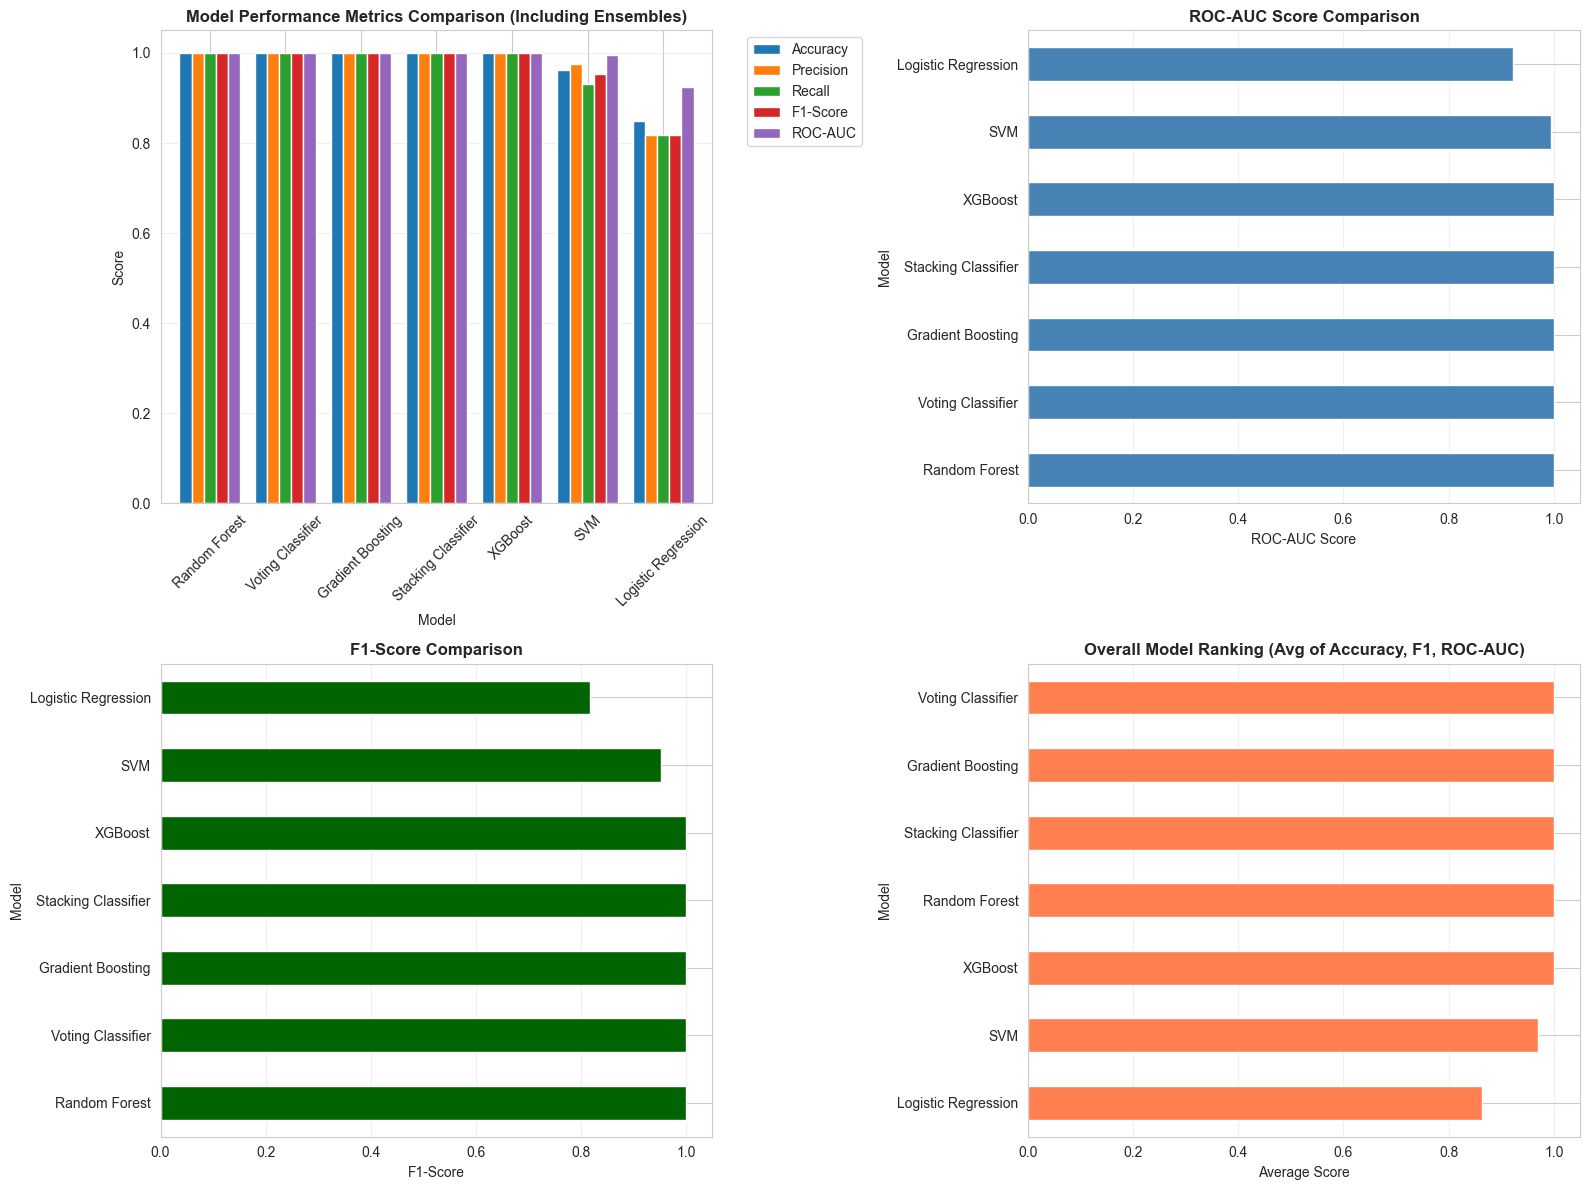

In [16]:
# Update results DataFrame with ensemble models
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Updated Model Performance Comparison (Including Ensembles):")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize updated results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df[metrics].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Model Performance Metrics Comparison (Including Ensembles)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ROC-AUC Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# F1-Score comparison
results_df['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='darkgreen')
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F1-Score', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
results_df['Overall Score'] = (
    results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
) / 3
overall_score = results_df['Overall Score'].sort_values(ascending=True)
overall_score.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Overall Model Ranking (Avg of Accuracy, F1, ROC-AUC)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

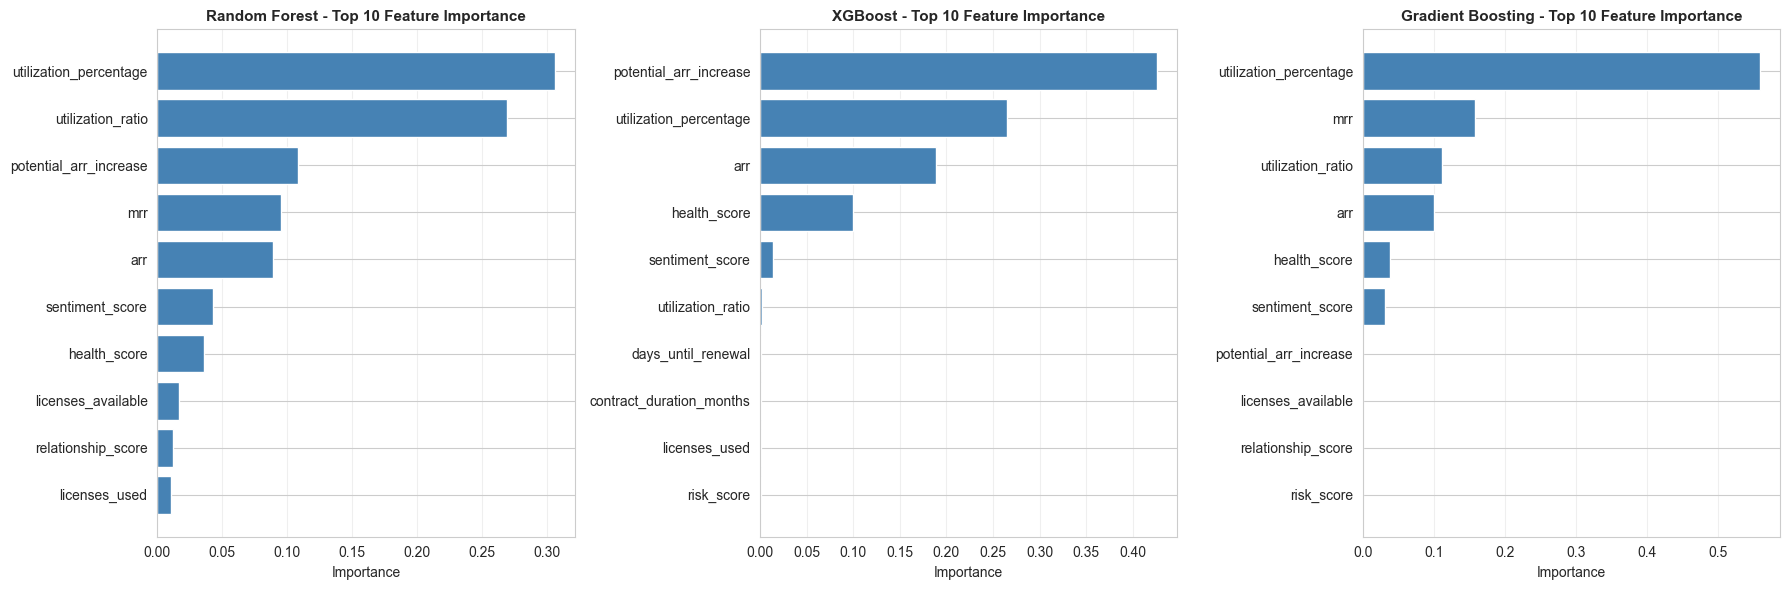


Random Forest - Feature Importance:
                 Feature  Importance
  utilization_percentage    0.306264
       utilization_ratio    0.269281
  potential_arr_increase    0.108787
                     mrr    0.094956
                     arr    0.089219
         sentiment_score    0.043171
            health_score    0.036038
      licenses_available    0.016960
      relationship_score    0.012153
           licenses_used    0.010718
              risk_score    0.010288
          licenses_total    0.001243
      days_until_renewal    0.000368
contract_duration_months    0.000251
                industry    0.000204
            company_size    0.000099


XGBoost - Feature Importance:
                 Feature  Importance
  potential_arr_increase    0.426510
  utilization_percentage    0.264675
                     arr    0.188653
            health_score    0.099963
         sentiment_score    0.014269
       utilization_ratio    0.002404
      days_until_renewal    0.000597
contra

In [17]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']

fig, axes = plt.subplots(1, len(tree_models), figsize=(18, 6))
if len(tree_models) == 1:
    axes = [axes]

for idx, name in enumerate(tree_models):
    if name in models:
        model = models[name]
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X.columns
            
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            # Plot top 10 features
            top_features = importance_df.head(10)
            axes[idx].barh(range(len(top_features)), top_features['importance'], color='steelblue')
            axes[idx].set_yticks(range(len(top_features)))
            axes[idx].set_yticklabels(top_features['feature'])
            axes[idx].set_xlabel('Importance', fontsize=10)
            axes[idx].set_title(f'{name} - Top 10 Feature Importance', 
                               fontsize=11, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, axis='x')
            axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

# Display feature importance tables
for name in tree_models:
    if name in models:
        model = models[name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print(f"\n{name} - Feature Importance:")
            print("=" * 60)
            print(importance_df.to_string(index=False))
            print()

## 11. Save Models

In [18]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create timestamp for model versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("Saving models...")
print("=" * 80)

# Save all individual models
saved_models = {}

for name, model in models.items():
    # Determine if model needs scaled features
    if name in ['Logistic Regression', 'SVM']:
        model_data = {
            'model': model,
            'scaler': scaler,
            'requires_scaling': True
        }
    else:
        model_data = {
            'model': model,
            'requires_scaling': False
        }
    
    filename = f"upsell_model_{name.lower().replace(' ', '_')}_{timestamp}.pkl"
    filepath = models_dir / filename
    joblib.dump(model_data, filepath)
    saved_models[name] = filepath
    print(f"✓ Saved {name} to {filepath}")

# Save ensemble models
ensemble_models_to_save = {
    'Voting Classifier': voting_clf,
    'Stacking Classifier': stacking_clf
}

for name, model in ensemble_models_to_save.items():
    model_data = {
        'model': model,
        'requires_scaling': False
    }
    filename = f"upsell_model_{name.lower().replace(' ', '_')}_{timestamp}.pkl"
    filepath = models_dir / filename
    joblib.dump(model_data, filepath)
    saved_models[name] = filepath
    print(f"✓ Saved {name} to {filepath}")

# Save the best model separately
best_model_name = results_df['Overall Score'].idxmax()
best_model = models.get(best_model_name) or ensemble_models_to_save.get(best_model_name)

if best_model:
    if best_model_name in ['Logistic Regression', 'SVM']:
        best_model_data = {
            'model': best_model,
            'scaler': scaler,
            'requires_scaling': True
        }
    else:
        best_model_data = {
            'model': best_model,
            'requires_scaling': False
        }
    
    best_model_path = models_dir / f"upsell_model_best_{timestamp}.pkl"
    joblib.dump(best_model_data, best_model_path)
    print(f"\n⭐ Saved Best Model ({best_model_name}) to {best_model_path}")

print("\n" + "=" * 80)

Saving models...
✓ Saved Logistic Regression to models\upsell_model_logistic_regression_20260214_200240.pkl
✓ Saved Random Forest to models\upsell_model_random_forest_20260214_200240.pkl
✓ Saved XGBoost to models\upsell_model_xgboost_20260214_200240.pkl
✓ Saved Gradient Boosting to models\upsell_model_gradient_boosting_20260214_200240.pkl
✓ Saved SVM to models\upsell_model_svm_20260214_200240.pkl
✓ Saved Voting Classifier to models\upsell_model_voting_classifier_20260214_200240.pkl
✓ Saved Stacking Classifier to models\upsell_model_stacking_classifier_20260214_200240.pkl

⭐ Saved Best Model (Random Forest) to models\upsell_model_best_20260214_200240.pkl



In [19]:
# Save preprocessing objects and metadata
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': list(X.columns),
    'categorical_features': available_categorical,
    'numerical_features': available_numerical
}

preprocessing_path = models_dir / f"upsell_preprocessing_{timestamp}.pkl"
joblib.dump(preprocessing_data, preprocessing_path)
print(f"✓ Saved preprocessing objects to {preprocessing_path}")

# Save model performance results
results_summary = {
    'timestamp': timestamp,
    'results': results_df.to_dict(),
    'best_model': best_model_name,
    'test_size': len(y_test),
    'train_size': len(y_train),
    'upsell_rate': float(y.mean())
}

results_path = models_dir / f"upsell_model_results_{timestamp}.pkl"
joblib.dump(results_summary, results_path)
print(f"✓ Saved model results to {results_path}")

# Also save results as CSV for easy viewing
results_csv_path = models_dir / f"upsell_model_results_{timestamp}.csv"
results_df.to_csv(results_csv_path)
print(f"✓ Saved model results (CSV) to {results_csv_path}")

print("\n" + "=" * 80)
print("All models and metadata saved successfully! 🎉")
print("=" * 80)

✓ Saved preprocessing objects to models\upsell_preprocessing_20260214_200240.pkl
✓ Saved model results to models\upsell_model_results_20260214_200240.pkl
✓ Saved model results (CSV) to models\upsell_model_results_20260214_200240.csv

All models and metadata saved successfully! 🎉


## 12. Final Summary & Best Model Recommendation

In [20]:
# Final summary
print("=" * 80)
print("FINAL MODEL COMPARISON SUMMARY (Including Ensembles)")
print("=" * 80)

# Best model by each metric
best_accuracy = results_df['Accuracy'].idxmax()
best_f1 = results_df['F1-Score'].idxmax()
best_roc_auc = results_df['ROC-AUC'].idxmax()

print(f"\n🏆 Best Model by Accuracy: {best_accuracy} ({results_df.loc[best_accuracy, 'Accuracy']:.4f})")
print(f"🏆 Best Model by F1-Score: {best_f1} ({results_df.loc[best_f1, 'F1-Score']:.4f})")
print(f"🏆 Best Model by ROC-AUC: {best_roc_auc} ({results_df.loc[best_roc_auc, 'ROC-AUC']:.4f})")

# Overall best model
best_overall = results_df['Overall Score'].idxmax()

print(f"\n⭐ Overall Best Model: {best_overall}")
print(f"   Accuracy: {results_df.loc[best_overall, 'Accuracy']:.4f}")
print(f"   Precision: {results_df.loc[best_overall, 'Precision']:.4f}")
print(f"   Recall: {results_df.loc[best_overall, 'Recall']:.4f}")
print(f"   F1-Score: {results_df.loc[best_overall, 'F1-Score']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_overall, 'ROC-AUC']:.4f}")
print(f"   Overall Score: {results_df.loc[best_overall, 'Overall Score']:.4f}")

print(f"\n📁 All models saved to: {models_dir.absolute()}")
print(f"📊 Total models saved: {len(saved_models) + 1}")  # +1 for best model
print(f"⭐ Best model saved as: upsell_model_best_{timestamp}.pkl")

print("\n" + "=" * 80)
print("Model Training and Saving Complete! 🎉")
print("=" * 80)

FINAL MODEL COMPARISON SUMMARY (Including Ensembles)

🏆 Best Model by Accuracy: Random Forest (1.0000)
🏆 Best Model by F1-Score: Random Forest (1.0000)
🏆 Best Model by ROC-AUC: Random Forest (1.0000)

⭐ Overall Best Model: Random Forest
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   ROC-AUC: 1.0000
   Overall Score: 1.0000

📁 All models saved to: d:\Internship\Renewal-Upsell-Advisor\Research\upsell_detection\models
📊 Total models saved: 8
⭐ Best model saved as: upsell_model_best_20260214_200240.pkl

Model Training and Saving Complete! 🎉
